In [3]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import pandas as pd

In [66]:
# plots I would like to make:
PATH = "/Users/kaijz/Desktop/NOAA/data"

taka = pd.read_csv(f"{PATH}/ecindex_ersstv5.csv")
mine = pd.read_csv(f"{PATH}/ecindex_ersstv6.csv")


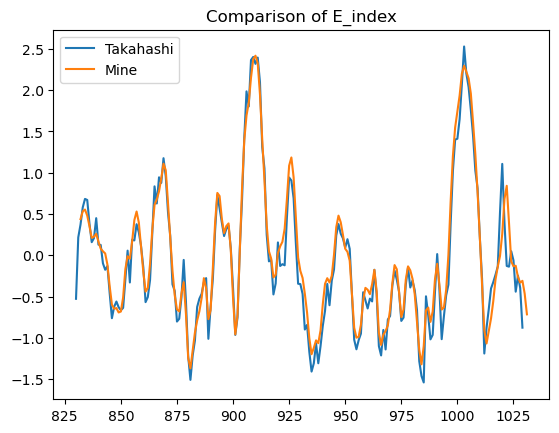

In [60]:
plt.title('Comparison of E_index')
plt.plot(taka['E_index'][-200:], label = 'Takahashi')
plt.plot(mine['E_index'][-200:], label='Mine')
plt.legend()

In [64]:
## correlation between both

print('Correlation E_index: ', mine['E_index'].corr(taka['E_index']))
print('Correlation C_index: ', mine['C_index'].corr(taka['C_index']))

Correlation E_index:  0.9706250601019822
Correlation C_index:  0.9657321404703453


In [67]:
ec = pd.read_csv(f"{PATH}/ecindex_ersstv6.csv")
wr = pd.read_csv(f"{PATH}/WR_ERA5_4WRs.csv")

wr = wr.rename(columns={wr.columns[0]: "date"})
wr["date"] = pd.to_datetime(wr["date"])
wr["year"] = wr["date"].dt.year
wr["month"] = wr["date"].dt.month


In [69]:
df = wr.merge(ec, on=["year", "month"], how="left")
df = df.sort_values("date").reset_index(drop=True)

print(f"Total daily samples: {len(df):,}")
print(f"Date range: {df['date'].min().date()} to {df['date'].max().date()}")
print(f"Missing E/C: {df['E_index'].isna().sum()}  (should be 0 if EC covers full WR range)")
print(f"\nWR class distribution:")
print(df["WR"].value_counts().sort_index())


Total daily samples: 31,390
Date range: 1940-01-01 to 2025-12-31
Missing E/C: 0  (should be 0 if EC covers full WR range)

WR class distribution:
WR
0    7650
1    6784
2    6183
3    6013
4    4760
Name: count, dtype: int64


## defining ENSO state categories

In [ ]:
# thresholds 1 sigmain either direction

sigma_E = ec["E_index"].std()
sigma_C = ec["C_index"].std()
print(f"\nsigma_E = {sigma_E},  sigma_C = {sigma_C}")

def enso_state(row, sE=sigma_E, sC=sigma_C):
    E, C = row["E_index"], row["C_index"]
    # E-warm: extreme warm regime, dom E component
    if E > sE and E > abs(C):
        return "E-warm"
    # E-cold (should be rare)
    if E < -sE and abs(E) > abs(C):
        return "E-cold"
    # C-warm: moderate warm in central Pacific
    if C > sC and abs(E) < sE:
        return "C-warm"
    # C-cold: captures La Nina
    if C < -sC and abs(E) < sE:
        return "C-cold"
    return "neutral"

df["enso_state"] = df.apply(enso_state, axis=1)



sigma_E = 0.9339874938839765,  sigma_C = 0.9521600585345937


<Axes: >

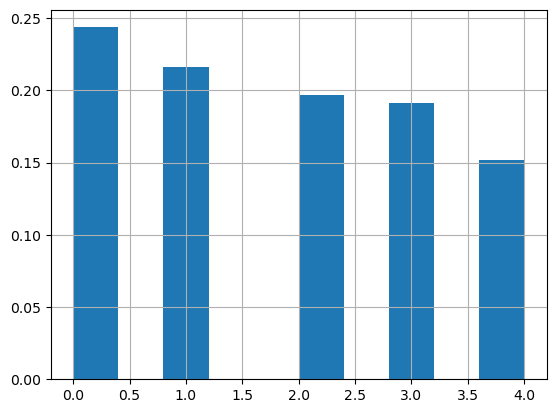

In [74]:
wr.WR.hist(bins=10, weights=np.ones_like(wr.WR) / len(wr.WR))

In [75]:
WR_NAMES = {0: "Pacific Trough", 1: "Greenland High", 2: "Pacific Ridge", 4: "Alaskan Ridge"}
df["WR_name"] = df["WR"].map(WR_NAMES)

   # cluster 1: Pacific Trouh
    # cluster 2: Greenland High
    # cluster 3: Pacific Ridge
    # cluster 4: Alaskan Ridge

# Season
def season_of(m):
    if m in (12, 1, 2): return "DJF"
    if m in (3, 4, 5):  return "MAM"
    if m in (6, 7, 8):  return "JJA"
    return "SON"
df["season"] = df["month"].apply(season_of)

print("\nENSO state counts (daily samples):")
print(df["enso_state"].value_counts())


ENSO state counts (daily samples):
enso_state
neutral    15715
C-cold      6017
E-cold      4333
E-warm      2899
C-warm      2426
Name: count, dtype: int64


In [76]:
## sapmle size table

table = df.groupby(["season", "enso_state", "WR_name"]).size().unstack("WR_name", fill_value=0)
table["TOTAL"] = table.sum(axis=1)
print("\n" + "="*70)
print("SAMPLE-SIZE TABLE (daily counts)")
print("="*70)
for s in ["DJF", "MAM", "JJA", "SON"]:
    print(f"\n--- {s} ---")
    print(table.loc[s] if s in table.index.get_level_values(0) else "(no data)")



SAMPLE-SIZE TABLE (daily counts)

--- DJF ---
WR_name     Alaskan Ridge  Greenland High  Pacific Ridge  Pacific Trough  \
enso_state                                                                 
C-cold                237             265            472             477   
C-warm                149             242            169             347   
E-cold                 55             101            142             125   
E-warm                 36              50             50             213   
neutral               449             858            812             928   

WR_name     TOTAL  
enso_state         
C-cold       1451  
C-warm        907  
E-cold        423  
E-warm        349  
neutral      3047  

--- MAM ---
WR_name     Alaskan Ridge  Greenland High  Pacific Ridge  Pacific Trough  \
enso_state                                                                 
C-cold                240             340            341             414   
C-warm                 80             1

In [85]:
table.to_csv(f"/Users/kaijz/Desktop/NOAA/ensoregimes/ensoregimes/results/sample_sizes_WR_x_ENSO_x_season.csv")


Time Series plots

KeyError: 3

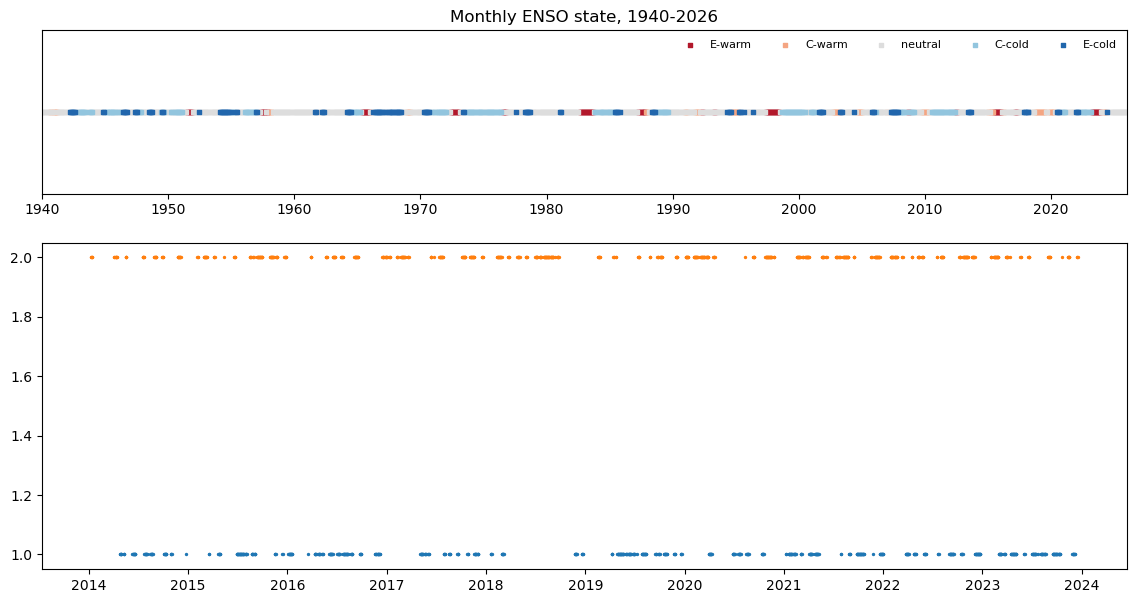

In [ ]:
# fig, (ax_full, ax_zoom) = plt.subplots(2, 1, figsize=(14, 7),
#                                        gridspec_kw={"height_ratios": [1, 2]})

# # --- Top panel: monthly ENSO state across full record ---
# ec_plot = ec.copy()
# ec_plot["date"] = pd.to_datetime(ec_plot[["year", "month"]].assign(day=15))
# ec_plot["enso_state"] = ec_plot.apply(enso_state, axis=1)
# state_colors = {
#     "E-warm":  "#b2182b",
#     "C-warm":  "#f4a582",
#     "neutral": "#dddddd",
#     "C-cold":  "#92c5de",
#     "E-cold":  "#2166ac",
# }
# for state, color in state_colors.items():
#     sub = ec_plot[ec_plot["enso_state"] == state]
#     ax_full.scatter(sub["date"], np.zeros(len(sub)), c=color, s=8,
#                     marker="s", label=state)
# ax_full.set_yticks([])
# ax_full.set_title("Monthly ENSO state, 1940-2026")
# ax_full.legend(loc="upper right", ncol=5, fontsize=8, frameon=False)
# ax_full.set_xlim(df["date"].min(), df["date"].max())

# # --- Bottom panel: zoom into a recent decade (2014-2024) with WR colored ---
# zoom_start, zoom_end = pd.Timestamp("2014-01-01"), pd.Timestamp("2024-01-01")
# dz = df[(df["date"] >= zoom_start) & (df["date"] < zoom_end)].copy()
# wr_colors = {1: "#1f77b4", 2: "#ff7f0e", 3: "#2ca02c", 4: "#d62728"}

# # WR as horizontal bands
# for wr_val, color in wr_colors.items():
#     mask = dz["WR"] == wr_val
#     ax_zoom.scatter(dz.loc[mask, "date"], np.full(mask.sum(), wr_val),
#                     c=color, s=2, label=WR_NAMES[wr_val])
# # ENSO state strip above WRs
# for state, color in state_colors.items():
#     sub = dz[dz["enso_state"] == state]
#     ax_zoom.scatter(sub["date"], np.full(len(sub), 5), c=color, s=2)
# ax_zoom.text(zoom_start, 5.3, "ENSO state ->", fontsize=8)

# ax_zoom.set_yticks([1, 2, 3, 4, 5])
# ax_zoom.set_yticklabels(["PT", "PR", "GH", "AR", "ENSO"])
# ax_zoom.set_xlim(zoom_start, zoom_end)
# ax_zoom.set_title("Daily WR labels + ENSO state, 2014-2024 (zoom)")
# ax_zoom.legend(loc="lower right", ncol=4, fontsize=8, frameon=False)

# plt.tight_layout()
# plt.savefig(f"{PATH}/fig_timeseries_WR_ENSO.png", dpi=140)
# plt.show()

KeyError: 0

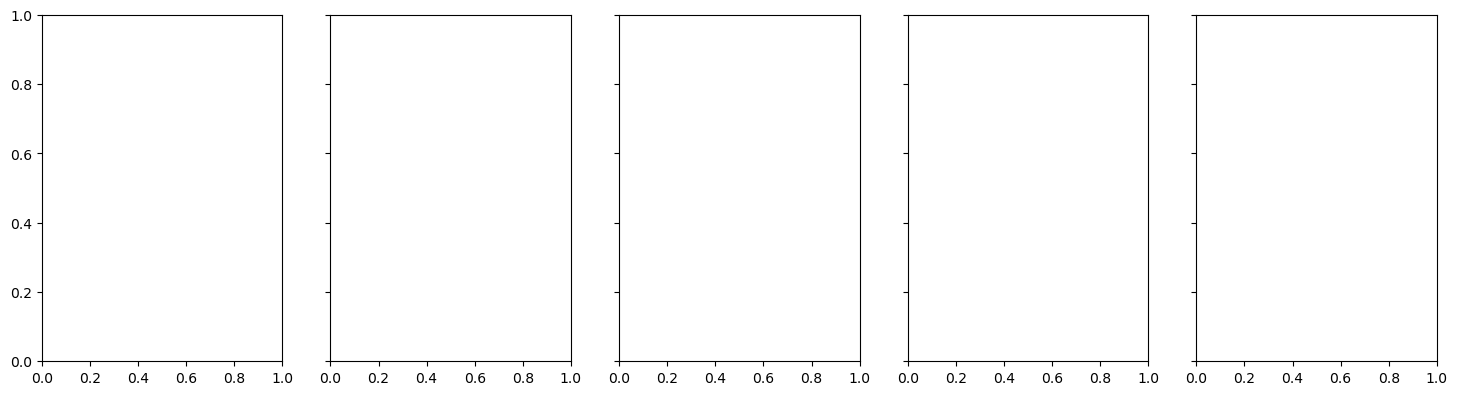

In [91]:
## WR frequencies by ENSO state, separately by season

state_order = ["C-cold", "neutral", "C-warm", "E-warm"]   # E-cold dropped if small
wr_order = [0, 1, 2, 3]
season_order = ["DJF", "MAM", "JJA", "SON", "year-round"]

def wr_freq_by_state(sub):
    """Return DataFrame of WR frequencies per ENSO state."""
    out = (sub.groupby(["enso_state", "WR"]).size()
              .unstack("WR", fill_value=0))
    out = out.div(out.sum(axis=1), axis=0) * 100  # convert to %
    return out

# Add a year-round panel
df_all = df.copy(); df_all["season"] = "year-round"
df_combined = pd.concat([df, df_all])

fig, axes = plt.subplots(1, 5, figsize=(18, 4.5), sharey=True)
for ax, season in zip(axes, season_order):
    sub = df_combined[df_combined["season"] == season]
    freq = wr_freq_by_state(sub)
    freq = freq.reindex(state_order).reindex(columns=wr_order)

    x = np.arange(len(state_order))
    width = 0.2
    for i, wr_val in enumerate(wr_order):
        vals = freq[wr_val].values
        ax.bar(x + (i - 1.5) * width, vals, width,
               color=wr_colors[wr_val], label=WR_NAMES[wr_val])
    ax.set_xticks(x); ax.set_xticklabels(state_order, rotation=20)
    ax.set_title(season)
    ax.axhline(25, color="k", lw=0.5, ls=":", alpha=0.5)  # uniform baseline
    if season == "DJF":
        ax.set_ylabel("WR frequency (%)")
    if season == "year-round":
        ax.legend(loc="upper right", fontsize=8)

# Annotate sample sizes under each bar group
for ax, season in zip(axes, season_order):
    sub = df_combined[df_combined["season"] == season]
    sizes = sub.groupby("enso_state").size().reindex(state_order, fill_value=0)
    for i, n in enumerate(sizes):
        ax.text(i, -8, f"n={n}", ha="center", fontsize=7, color="gray")

plt.suptitle("WR frequency stratified by ENSO state, by season", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(f"{PATH}/fig_WR_freq_by_ENSO_state.png", dpi=140, bbox_inches="tight")
plt.show()

In [90]:
wr_order

[1, 2, 3, 4]